# WIE2003 Introduction to Data Science
# Data-Driven Property Price Analysis and Classification System (Machine Learning Phase)




## Initial loading cleaned KL_Property dataset


**Import Library**

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

**Load KL Property data**

In [2]:
# Mount dataset to drive
drive.mount('/content/drive')

# Path to your CSV file
csv_path = '/content/drive/MyDrive/IDS Project/Dataset/KL_Property.csv'

# Load dataset
df = pd.read_csv(csv_path)

# Display first few rows
df.head()

Mounted at /content/drive


,Property Type,District,Mukim,"Month, Year of Transaction Date",Tenure,Land/Parcel Area (sqm),Main Floor Area (sqm),Unit Level,Transaction Price,Property Category,Effective Area (sqm),Transaction Year,Transaction Month,Land/Parcel Area (sqft),Main Floor Area (sqft),Effective Area (sqft),price_per_sqft
0,1 - 1 1/2 STOREY SEMI-DETACHED,KUALA LUMPUR,KUALA LUMPUR TOWN CENTRE,2024-01-01,FREEHOLD,293.38,138.0,0.0,1600000.0,LANDED,293.38,2024,1,3157.9,1485.4,3157.9,506.66
1,1 - 1 1/2 STOREY SEMI-DETACHED,KUALA LUMPUR,KUALA LUMPUR TOWN CENTRE,2024-08-01,FREEHOLD,294.40,102.0,0.0,1200000.0,LANDED,294.40,2024,8,3168.9,1097.9,3168.9,378.68
2,1 - 1 1/2 STOREY SEMI-DETACHED,KUALA LUMPUR,KUALA LUMPUR TOWN CENTRE,2021-09-01,FREEHOLD,293.38,140.0,0.0,1500000.0,LANDED,293.38,2021,9,3157.9,1506.9,3157.9,475.00
3,1 - 1 1/2 STOREY SEMI-DETACHED,KUALA LUMPUR,KUALA LUMPUR TOWN CENTRE,2022-10-01,FREEHOLD,441.85,169.0,0.0,1550000.0,LANDED,441.85,2022,10,4756.0,1819.1,4756.0,325.90
4,1 - 1 1/2 STOREY SEMI-DETACHED,KUALA LUMPUR,KUALA LUMPUR TOWN CENTRE,2024-06-01,FREEHOLD,565.28,145.0,0.0,2100000.0,LANDED,565.28,2024,6,6084.6,1560.8,6084.6,345.13


**Checking available features in the cleaned dataset before proceeding with first phase of feature engineering**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24132 entries, 0 to 24131
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Property Type                    24132 non-null  object 
 1   District                         24132 non-null  object 
 2   Mukim                            24132 non-null  object 
 3   Month, Year of Transaction Date  24132 non-null  object 
 4   Tenure                           24132 non-null  object 
 5   Land/Parcel Area (sqm)           24129 non-null  float64
 6   Main Floor Area (sqm)            5135 non-null   float64
 7   Unit Level                       24132 non-null  float64
 8   Transaction Price                24132 non-null  float64
 9   Property Category                24132 non-null  object 
 10  Effective Area (sqm)             24132 non-null  float64
 11  Transaction Year                 24132 non-null  int64  
 12  Transaction Month 



##Feature Engineering



**Create the Price_Category column based on the thresholds found in the Deep Analysis**

There are two code cells in target binning phase, the commented code cell shows the code that creates 4 classes of property category. However, the model trained using 4 class price category is relatively low, where the model fails to learn and differentiate between Mid-Range and High-End properties. Hence, the team proceeded with the methodology of dividing KL properties into 3 classes of "Budget", "Mid-Range" and "Luxury".

In [4]:
'''
# 1. Define the manual bins and labels based on your EDA strategy
price_bins = [0, 400000, 850000, 1500000, float('inf')]

# Using numeric labels (0,1,2,3) is better for the ML model's y-variable
price_labels = [0, 1, 2, 3]

# 2. Apply the manual cut
df['Price_Category'] = pd.cut(
    df['Transaction Price'],
    bins=price_bins,
    labels=price_labels,
    right=False,
    include_lowest=True
)

# 3. Check for any properties that failed to bin (NaNs)
print(f"Total NaNs in Price_Category: {df['Price_Category'].isna().sum()}")

# 4. Monitor the Class Imbalance (Crucial for GA2 methodology)
print("\n--- Manual Price Category Counts ---")
counts = df['Price_Category'].value_counts().sort_index()
label_names = ['Budget (<400k)', 'Mid-Range (400k-850k)', 'High-End (850k-1.5M)', 'Luxury (>1.5M)']

for i, count in enumerate(counts):
    print(f"Class {i} ({label_names[i]}): {count} transactions")
'''

'\n# 1. Define the manual bins and labels based on your EDA strategy\nprice_bins = [0, 400000, 850000, 1500000, float(\'inf\')]\n\n# Using numeric labels (0,1,2,3) is better for the ML model\'s y-variable\nprice_labels = [0, 1, 2, 3]\n\n# 2. Apply the manual cut\ndf[\'Price_Category\'] = pd.cut(\n    df[\'Transaction Price\'],\n    bins=price_bins,\n    labels=price_labels,\n    right=False,\n    include_lowest=True\n)\n\n# 3. Check for any properties that failed to bin (NaNs)\nprint(f"Total NaNs in Price_Category: {df[\'Price_Category\'].isna().sum()}")\n\n# 4. Monitor the Class Imbalance (Crucial for GA2 methodology)\nprint("\n--- Manual Price Category Counts ---")\ncounts = df[\'Price_Category\'].value_counts().sort_index()\nlabel_names = [\'Budget (<400k)\', \'Mid-Range (400k-850k)\', \'High-End (850k-1.5M)\', \'Luxury (>1.5M)\']\n\nfor i, count in enumerate(counts):\n    print(f"Class {i} ({label_names[i]}): {count} transactions")\n'

In [5]:
# 1. Define the 3-Class Bins
# We merge the middle to create a 'Market-Rate' powerhouse class
price_bins = [0, 500000, 1200000, float('inf')]
price_labels = [0, 1, 2] # Affordable, Market-Rate, Luxury

# 2. Apply the manual cut
df['Price_Category'] = pd.cut(
    df['Transaction Price'],
    bins=price_bins,
    labels=price_labels,
    right=False,
    include_lowest=True
)

# 3. Check for any properties that failed to bin (NaNs)
print(f"Total NaNs in Price_Category: {df['Price_Category'].isna().sum()}")

# 4. Monitor the Class Imbalance (Crucial for GA2 methodology)
print("\n--- Manual Price Category Counts ---")
counts = df['Price_Category'].value_counts().sort_index()
label_names = ['Budget (<500k)', 'Mid-Range (500k-1.2M)', 'Luxury (>1.5M)']

for i, count in enumerate(counts):
    print(f"Class {i} ({label_names[i]}): {count} transactions")


Total NaNs in Price_Category: 0

--- Manual Price Category Counts ---
Class 0 (Budget (<500k)): 11376 transactions
Class 1 (Mid-Range (500k-1.2M)): 8914 transactions
Class 2 (Luxury (>1.5M)): 3842 transactions


**Visualization after binning**

For the 3 class binning, we can observe that "budget" property is the majority by having a number of 11376 properties under this category, followed by "mid-range" properties with a count of 8914, and "luxury" property having the least count of 3842 properties.

/tmp/ipykernel_3356/3361469048.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Price_Category', palette='viridis')


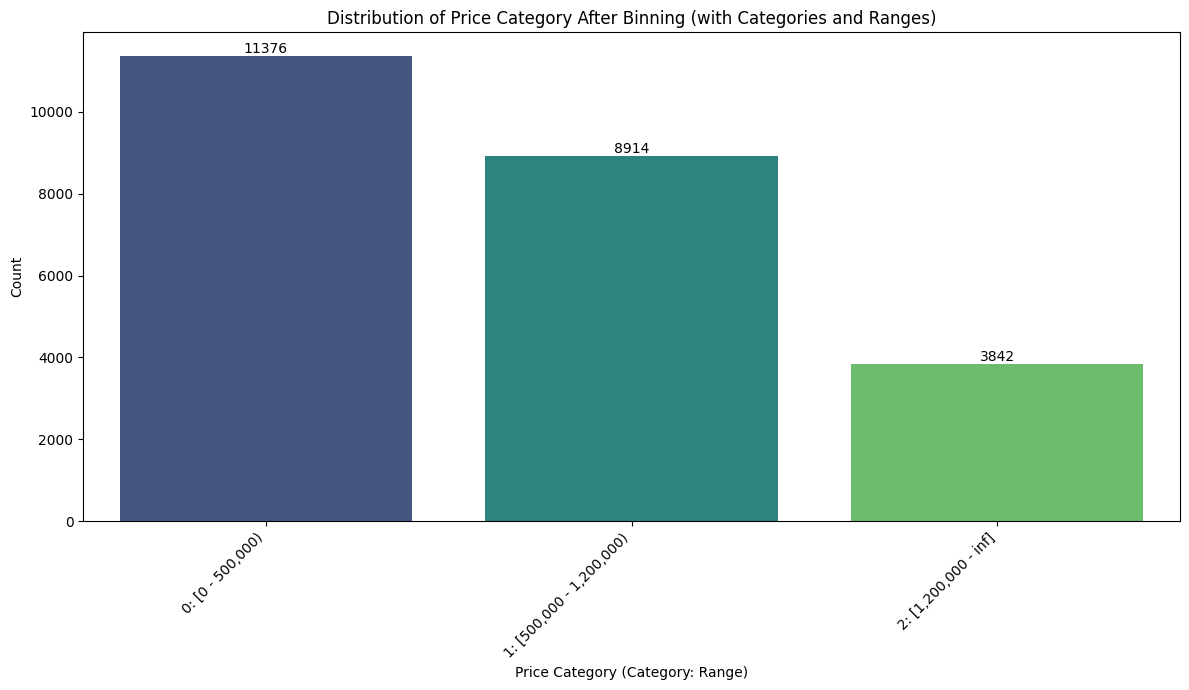

In [6]:
# Create descriptive labels for the price categories
price_labels_description = []
for i in range(len(price_bins) - 1):
    lower_bound = f"{price_bins[i]:,.0f}"
    upper_bound = f"{price_bins[i+1]:,.0f}"
    if i == len(price_bins) - 2:
        price_labels_description.append(f"[{lower_bound} - {upper_bound}]")
    else:
        price_labels_description.append(f"[{lower_bound} - {upper_bound})")

# Combine numerical labels with descriptive ranges
combined_labels = [f"{price_labels[i]}: {price_labels_description[i]}" for i in range(len(price_labels))]

plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='Price_Category', palette='viridis')
plt.title('Distribution of Price Category After Binning (with Categories and Ranges)')
plt.xlabel('Price Category (Category: Range)')
plt.ylabel('Count')

# Set custom x-axis tick labels
plt.xticks(ticks=range(len(combined_labels)), labels=combined_labels, rotation=45, ha='right')

# Add exact count labels on top of each bar
for container in plt.gca().containers:
    plt.gca().bar_label(container)

plt.tight_layout()
plt.show()

**Stratified Splitting**

This block runs a 80/20 Train-Test Split using a Stratified sampling strategy. The original dataset is divided into a training partition 19305 rows to fit the machine learning algorithms, and an independent testing partition 4827 rows that acts as a test to evaluate the generalized performance of the model on unseen data. By setting a fixed random_state=42, we guarantee that this split is perfectly reproducible.

If we used a standard random split, there is a high risk that the minority class (Luxury) would be randomly underrepresented in the test set. Stratification forces the split to respect the exact proportions of the real world, ensuring the model's evaluation is entirely fair and realistic.

By isolating 20% of the data completely before any scaling, encoding, or hyperparameter tuning occurs, we prevent Data Leakage.

In [7]:
# Define features (X) and target (y)
# We drop price-related columns to prevent the model from 'cheating'
X = df.drop(['Transaction Price', 'Price_Category', 'price_per_sqft'], axis=1)
y = df['Price_Category']

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# --- VERIFICATION ---
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")
print("\nTarget Distribution Check (Should be proportional):")
print(y_train.value_counts(normalize=True).sort_index())

Training set size: 19305 rows
Testing set size: 4827 rows

Target Distribution Check (Should be proportional):
Price_Category
0    0.471432
1    0.369386
2    0.159182
Name: proportion, dtype: float64


**Ordinal Mukim Ranking**

This cell implements an ordinal target-encoding strategy to transform the raw, high-cardinality categorical variable Mukim (neighborhood regions) into a meaningful numerical feature called Mukim_Rank. Instead of randomly assigning numbers, the algorithm calculates the median price-per-square-foot (price_per_sqft) for every individual Mukim using exclusively the training data indices. These regions are then sorted in ascending order and assigned a consecutive integer rank from 1 (the most affordable neighborhood) up to N (the most expensive/prestigious neighborhood). This derived ranking is mapped back onto both the training and testing sets, with a median-fallback safeguard implemented for the test set to handle any unseen locations securely.

Standard categorical encoding methods (like converting text to arbitrary numbers $0, 1, 2, 3\dots$) trick the model into thinking neighboring categories have a mathematical distance between them that doesn't exist. By restructuring the column into an ordinal scale based on actual value density (1 = Cheapest, N = Most Expensive), we inject a direct proxy for Location Prestige. This allows algorithms like Random Forest to make highly efficient mathematical splits (e.g., "If Mukim_Rank > 25, look for luxury patterns"), mimicking how real human appraisers value a neighborhood.

In [8]:
# Calculate Median Price per Sqft for each Mukim using ONLY training indices
train_prices = df.loc[X_train.index, 'price_per_sqft']
mukim_stats = pd.DataFrame({'Mukim': X_train['Mukim'], 'PSF': train_prices})

# Create the Prestige Rank (1 = Cheapest, N = Most Expensive)
mukim_rank_series = mukim_stats.groupby('Mukim')['PSF'].median().sort_values()
mukim_mapping = {name: rank for rank, name in enumerate(mukim_rank_series.index, 1)}

# Apply mapping to both sets
X_train['Mukim_Rank'] = X_train['Mukim'].map(mukim_mapping)
# For test set, fill any new/unseen Mukims with the median rank
X_test['Mukim_Rank'] = X_test['Mukim'].map(mukim_mapping).fillna(X_train['Mukim_Rank'].median())

# --- VERIFICATION ---
print("Top 5 'Most Prestigious' Mukims (Highest Rank):")
print(mukim_rank_series.tail(5))
print(f"\nVerification: 'Mukim_Rank' created. Missing values in test: {X_test['Mukim_Rank'].isna().sum()}")

Top 5 'Most Prestigious' Mukims (Highest Rank):
Mukim
MUKIM SETAPAK               393.930
MUKIM PETALING              406.515
KUALA LUMPUR TOWN CENTRE    451.610
MUKIM KUALA LUMPUR          464.520
MUKIM BATU                  543.930
Name: PSF, dtype: float64

Verification: 'Mukim_Rank' created. Missing values in test: 0


**Numerical Scaling:
Apply StandardScaler to Effective_Area and Unit_Level.**


Z-score standardization is applied to the numerical features Effective Area (sqft) and Unit Level using scikit-learn's StandardScaler.The process calculates the empirical mean ($\mu$) and standard deviation ($\sigma$) exclusively from the training dataset (X_train) during the .fit_transform() phase. These calculated statistics are then used to scale the training features. Crucially, the testing dataset (X_test) is transformed using the exact same training parameters via .transform(). This mathematical operation centers the data distributions around a mean of 0 and scales them to a standard deviation of 1.

In [9]:
scaler = StandardScaler()
num_cols = ['Effective Area (sqft)', 'Unit Level']

# Fit on Train, then Transform both
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# --- VERIFICATION ---
print("Scaler Verification (Training Mean should be ~0 and Std should be ~1):")
print(X_train[num_cols].describe().loc[['mean', 'std']])

Scaler Verification (Training Mean should be ~0 and Std should be ~1):
      Effective Area (sqft)    Unit Level
mean          -2.281981e-17  1.472246e-17
std            1.000026e+00  1.000026e+00


**Categorical Encoding:**

**One-Hot Encoding: for Property Type, Property Category,Tenure and Mukim**

One-hot encoding is applied to `Property Type`, `Property Category`, and `Tenure` columns. This converts categorical variables into a format that can be provided to machine learning algorithms. Each unique category value becomes a new column, and a '1' is placed in the column corresponding to the observation's category, and '0's in the others. This prevents the model from assuming any ordinal relationship between categories.

In [10]:
# Initialize Encoder (ignoring unknown categories in test set to prevent crashes)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cat_cols = ['Property Type', 'Property Category', 'Tenure']

# Fit/Transform and convert to DataFrames
ohe_train_df = pd.DataFrame(ohe.fit_transform(X_train[cat_cols]),
                            columns=ohe.get_feature_names_out(), index=X_train.index)
ohe_test_df = pd.DataFrame(ohe.transform(X_test[cat_cols]),
                           columns=ohe.get_feature_names_out(), index=X_test.index)

# Combine with our previous features (Mukim_Rank and Scaled Numerics)
X_train_final = pd.concat([X_train[['Mukim_Rank'] + num_cols], ohe_train_df], axis=1)
X_test_final = pd.concat([X_test[['Mukim_Rank'] + num_cols], ohe_test_df], axis=1)

# --- VERIFICATION ---
print(f"Final Feature Matrix Shape: {X_train_final.shape}")
print("\nFinal Columns Prepared for Model Training:")
print(X_train_final.columns.tolist())

Final Feature Matrix Shape: (19305, 18)

Final Columns Prepared for Model Training:
['Mukim_Rank', 'Effective Area (sqft)', 'Unit Level', 'Property Type_1 - 1 1/2 STOREY SEMI-DETACHED', 'Property Type_1 - 1 1/2 STOREY TERRACED', 'Property Type_2 - 2 1/2 STOREY SEMI-DETACHED', 'Property Type_2 - 2 1/2 STOREY TERRACED', 'Property Type_CLUSTER HOUSE', 'Property Type_CONDOMINIUM/APARTMENT', 'Property Type_DETACHED', 'Property Type_FLAT', 'Property Type_LOW-COST FLAT', 'Property Type_LOW-COST HOUSE', 'Property Type_TOWN HOUSE', 'Property Category_LANDED', 'Property Category_STRATA', 'Tenure_FREEHOLD', 'Tenure_LEASEHOLD']


**Feature Synthesis**

This code block performs domain-specific feature engineering by injecting complex market relationships directly into the feature matrix. It creates three new interaction variables:Log_Area: Applies a natural log transformation ($\ln(1+x)$) to the raw square footage to normalize its heavily skewed distribution.Year_Rank: Multiplies the Transaction Year by the Mukim_Rank to capture time-based market shifts across different locations.Area_Prestige: Multiplies the newly stabilized Log_Area by the Mukim_Rank to capture the "value density" of a property.

**Justification**
1. By applying np.log1p, we compress the variance of massive properties, helping the tree-based Random Forest establish clean, generalized decision boundaries.
2. By manually multiplying Log_Area by Mukim_Rank, you create a "Value Density Index." This gives the Random Forest a direct metric for luxury, which is why your feature importance plot ranked this as the #2 most influential driver in the entire project.
3. Multiplying the year by the location rank allows the model to adjust its price category thresholds based on when the transaction actually occurred, serving as a proxy for inflation or market cooling.

In [11]:
# --- FEATURE SYNTHESIS ---

# A. Log Area: Use RAW X_train/X_test to avoid negative scaled values
# We pull 'Effective Area (sqft)' from X_train (unscaled)
X_train_final['Log_Area'] = np.log1p(X_train['Effective Area (sqft)'])
X_test_final['Log_Area'] = np.log1p(X_test['Effective Area (sqft)'])

# B. Year Rank: Pull 'Transaction Year' from the raw X_train/X_test
# Note: We pull from 'X_train' because it's not in 'X_train_final' yet
X_train_final['Year_Rank'] = X_train['Transaction Year'] * X_train_final['Mukim_Rank']
X_test_final['Year_Rank'] = X_test['Transaction Year'] * X_test_final['Mukim_Rank']

# C. Area Prestige: Use our new Log_Area for better scaling
X_train_final['Area_Prestige'] = X_train_final['Log_Area'] * X_train_final['Mukim_Rank']
X_test_final['Area_Prestige'] = X_test_final['Log_Area'] * X_test_final['Mukim_Rank']

# --- VERIFICATION ---
print("✅ Synthesis Complete!")
print(f"Total Columns now: {X_train_final.shape[1]}")
print("\nCheck for NaN (should be 0):")
print(X_train_final[['Log_Area', 'Year_Rank', 'Area_Prestige']].isna().sum())

✅ Synthesis Complete!
Total Columns now: 21

Check for NaN (should be 0):
Log_Area         940
Year_Rank          0
Area_Prestige    940
dtype: int64


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


This next code cell functions as a data-integrity checkpoint by dynamically identifying and resolving missing (NaN) values introduced during the feature synthesis phase.

The script isolates any features containing gaps and applies a Median Imputation strategy. It calculates the mathematical median of each problematic column using only the training dataset partition (X_train_final). This calculated scalar is then used to fill the empty cells in both the training matrix and the testing matrix (X_test_final), concluding with a final zero-sum verification check to ensure the entire feature space is clean.

In [12]:
# --- NAN SAFETY NET ---

# 1. Identify which columns have NaNs
nan_counts = X_train_final.isna().sum()
cols_with_nan = nan_counts[nan_counts > 0].index.tolist()

if len(cols_with_nan) > 0:
    print(f"⚠️ Found NaNs in: {cols_with_nan}")

    # 2. Fix NaNs using Median Imputation
    # We use the training median to fill gaps in both Train and Test (to avoid leakage)
    for col in cols_with_nan:
        filler = X_train_final[col].median()
        X_train_final[col] = X_train_final[col].fillna(filler)
        X_test_final[col] = X_test_final[col].fillna(filler)

    print("✅ All NaNs have been filled with median values.")
else:
    print("✅ No NaNs detected. Your feature matrix is clean!")

# 3. Final Check (Should all be 0)
print("\nFinal NaN Check:")
print(X_train_final.isna().sum().sum())

⚠️ Found NaNs in: ['Log_Area', 'Area_Prestige']
✅ All NaNs have been filled with median values.

Final NaN Check:
0


**Save as .pkl file**

In [13]:
# Bundle all objects into a single dictionary
preprocessor_bundle = {
    'scaler': scaler,
    'ohe': ohe,
    'mukim_mapping': mukim_mapping,
    'feature_names': X_train_final.columns.tolist() # Helpful for the dashboard to know the exact column order!
}

# Save as a single package
with open('property_preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor_bundle, f)

print("✅ All preprocessing tools bundled into 'property_preprocessor.pkl'")

✅ All preprocessing tools bundled into 'property_preprocessor.pkl'


**Finalizing the training data and testing data**

This part saves all the training and testing data into pkl file for better control in data during the training phase (can just rerun training cells that fetch data directly from pkl instead of dataframes). The printout shows the status of each data files needed and their respective size for troubleshooting purposes.

In [14]:
# 1. Define the Dictionary for Datasets
# We save these separately so team members can load exactly what they need
datasets_to_save = {
    'X_train_final.pkl': X_train_final,
    'y_train.pkl': y_train,
    'X_test_final.pkl': X_test_final,
    'y_test.pkl': y_test
}

# 2. Execute the Save Loop
print("--- Saving Project Artifacts ---")
for filename, obj in datasets_to_save.items():
    with open(filename, 'wb') as f:
        pickle.dump(obj, f)
    print(f"✅ Saved: {filename}")

# 3. Final Verification Check
files_to_verify = [
    'X_train_final.pkl', 'y_train.pkl',
    'X_test_final.pkl', 'y_test.pkl',
    'property_preprocessor.pkl'
]

print("\n--- Final Artifact Verification ---")
for file in files_to_verify:
    if os.path.exists(file):
        size_kb = os.path.getsize(file) / 1024
        print(f"{file:<25} | Status: ✅ | Size: {size_kb:>7.2f} KB")
    else:
        print(f"{file:<25} | Status: ❌ STILL MISSING")

--- Saving Project Artifacts ---
✅ Saved: X_train_final.pkl
✅ Saved: y_train.pkl
✅ Saved: X_test_final.pkl
✅ Saved: y_test.pkl

--- Final Artifact Verification ---
X_train_final.pkl         | Status: ✅ | Size: 3319.57 KB
y_train.pkl               | Status: ✅ | Size:  321.43 KB
X_test_final.pkl          | Status: ✅ | Size:  831.14 KB
y_test.pkl                | Status: ✅ | Size:   81.06 KB
property_preprocessor.pkl | Status: ✅ | Size:    2.09 KB


##Model Training

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score

# --- NEW: Calculate weights for XGBoost ---
# This ensures every class is treated as equally important despite size differences
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 1. Initialize all models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1), # KNN doesn't support class_weights directly
    "XGBoost": xgb.XGBClassifier(objective='multi:softmax', num_class=4, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(objective='multiclass', class_weight='balanced', num_class=4, random_state=42, n_jobs=-1, verbose=-1)
}

# 2. Training Loop
training_results = {}

print("--- Starting Balanced Unified Model Training ---")
for name, model in models.items():
    print(f"Training {name}...")

    # XGBoost requires sample_weight during the .fit() call specifically
    if name == "XGBoost":
        model.fit(X_train_final, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train_final, y_train)

    y_train_pred = model.predict(X_train_final)
    train_acc = accuracy_score(y_train, y_train_pred)
    training_results[name] = train_acc
    print(f"{name} Training Accuracy: {train_acc:.4f}")

# 3. Final Ranking
ranking = sorted(training_results.items(), key=lambda x: x[1], reverse=True)
print("\n--- Preliminary Model Ranking (Training Set) ---")
for rank, (name, acc) in enumerate(ranking, 1):
    print(f"{rank}. {name}: {acc:.4f}")

--- Starting Balanced Unified Model Training ---
Training Logistic Regression...
Logistic Regression Training Accuracy: 0.7602
Training Random Forest...
Random Forest Training Accuracy: 0.9708
Training KNN...
KNN Training Accuracy: 0.8568
Training XGBoost...
XGBoost Training Accuracy: 0.8827
Training LightGBM...
LightGBM Training Accuracy: 0.8555

--- Preliminary Model Ranking (Training Set) ---
1. Random Forest: 0.9708
2. XGBoost: 0.8827
3. KNN: 0.8568
4. LightGBM: 0.8555
5. Logistic Regression: 0.7602


###Unified Testing and Validation

The technique implemented in this code block is a Unified Holdout Validation and Multi-Metric Testing strategy, conceptually framed as the "Final Exam" for the machine learning pipeline.

Instead of relying on training scores, this module programmatically iterates through every model in your experimental repository (Logistic Regression, Random Forest, KNN, XGBoost, and LightGBM) and evaluates them against an entirely isolated, unseen testing partition (X_test_final). The strategy forces a multi-dimensional performance assessment by simultaneously computing overall Accuracy, extracting a granular Classification Report (Precision, Recall, and F1-Score for each price bracket), ranking the models objectively based on empirical test performance, and mapping a Confusion Matrix for the winning algorithm.

--- Starting Unified Model Testing (The Final Exam) ---

[Logistic Regression] Test Accuracy: 0.7696
              precision    recall  f1-score   support

      Budget       0.88      0.84      0.86      2275
   Mid-Range       0.70      0.68      0.69      1783
      Luxury       0.65      0.78      0.71       769

    accuracy                           0.77      4827
   macro avg       0.74      0.76      0.75      4827
weighted avg       0.77      0.77      0.77      4827


[Random Forest] Test Accuracy: 0.8488
              precision    recall  f1-score   support

      Budget       0.90      0.90      0.90      2275
   Mid-Range       0.80      0.80      0.80      1783
      Luxury       0.82      0.82      0.82       769

    accuracy                           0.85      4827
   macro avg       0.84      0.84      0.84      4827
weighted avg       0.85      0.85      0.85      4827


[KNN] Test Accuracy: 0.8001
              precision    recall  f1-score   support

      Budget  

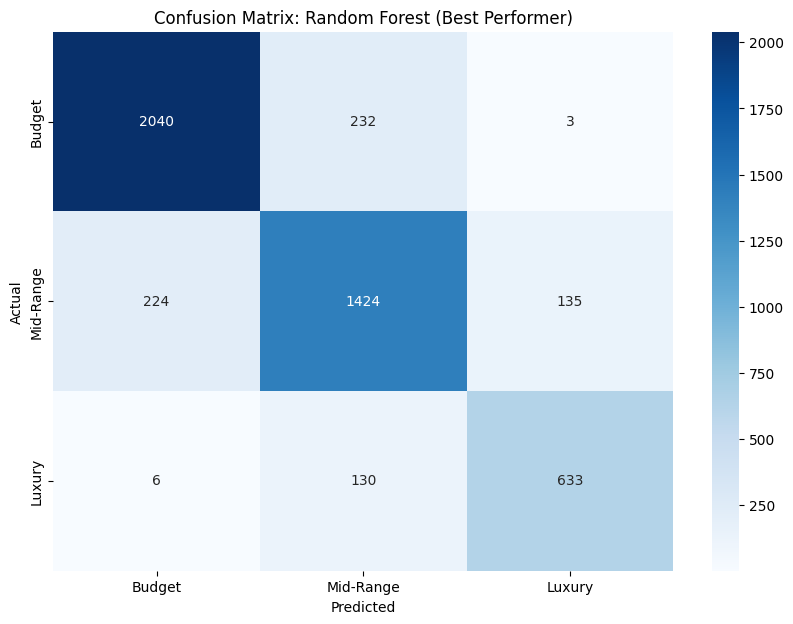

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

test_results = {}

print("--- Starting Unified Model Testing (The Final Exam) ---")

# 1. Testing Loop
for name, model in models.items():
    # Make predictions on the UNSEEN test set
    y_pred = model.predict(X_test_final)

    # Calculate Accuracy
    acc = accuracy_score(y_test, y_pred)
    test_results[name] = acc

    print(f"\n[{name}] Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Budget', 'Mid-Range', 'Luxury']))

# 2. Final Ranking based on TEST Accuracy
final_ranking = sorted(test_results.items(), key=lambda x: x[1], reverse=True)

print("\n--- FINAL MODEL RANKING (Based on Test Set) ---")
for rank, (name, acc) in enumerate(final_ranking, 1):
    print(f"{rank}. {name}: {acc:.4f}")

# 3. Visualizing the Best Model's Confusion Matrix
best_model_name = final_ranking[0][0]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_final)

plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Budget', 'Mid-Range', 'Luxury'],
            yticklabels=['Budget', 'Mid-Range', 'Luxury'])
plt.title(f'Confusion Matrix: {best_model_name} (Best Performer)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Hyperparameter Tuning

**Custom Class Weighting**

Establishe a Manual Class-Weight Balancing strategy for the 3-class target variable. Instead of leaving the algorithm to treat every property tier with equal mathematical importance, a custom dictionary (custom_weights) explicitly defines penalty multipliers for each class:

Class 0 (Budget): 1.0 (Baseline weight)

Class 1 (Mid-Range): 1.0 (Baseline weight)

Class 2 (Luxury): 1.5 (A 50% increase in mathematical importance)

Using pandas, this dictionary is mapped directly to the training index, transforming the static target array into a dynamic vector of sample weights (custom_sample_weights) that forces cost-sensitive learning across your gradient-boosting and tree-based models.

In [17]:
from sklearn.utils.class_weight import compute_sample_weight

# 0: Budget, 1: Mid-Range, 2: High-End, 3: Luxury
# We give High-End and Luxury a 'gentle' boost instead of the heavy 'balanced' boost
custom_weights = {0: 1.0, 1: 1.0, 2: 1.5}

# Create sample weights for XGBoost and the Final Ensemble fit
# This maps the dictionary to every row in your training labels
custom_sample_weights = pd.Series(y_train).map(custom_weights).values

print("✅ Custom weights defined. Ready to tune.")

✅ Custom weights defined. Ready to tune.


### Tuning for XGBoost

In [18]:
from sklearn.model_selection import GridSearchCV

# 1. Grid remains the same
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 2. Initialize Tuner
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(objective='multi:softmax', num_class=4, random_state=42),
    param_grid=param_grid,
    scoring='f1_weighted', # F1-Weighted is much better than Accuracy for balanced classes
    cv=3,
    verbose=1,
    n_jobs=-1
)

print("--- Starting Custom-Weighted Tuning for XGBoost ---")
grid_search.fit(X_train_final, y_train, sample_weight=custom_sample_weights)

print(f"\nBest Parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_
final_pred = best_model.predict(X_test_final)
print(f"Final Balanced Tuned Accuracy: {accuracy_score(y_test, final_pred):.4f}")

--- Starting Custom-Weighted Tuning for XGBoost ---
Fitting 3 folds for each of 48 candidates, totalling 144 fits

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.8}
Final Balanced Tuned Accuracy: 0.8469


###Tuning for LightGBM

In [19]:
# 1. Focused grid for LightGBM
lgbm_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'feature_fraction': [0.8, 0.9]
}

# 2. Initialize Tuner with BALANCED base estimator
lgbm_grid = GridSearchCV(
    estimator=lgb.LGBMClassifier(objective='multiclass', class_weight=custom_weights, random_state=42, verbose=-1),
    param_grid=lgbm_param_grid,
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    n_jobs=-1
)

print("--- Tuning LightGBM ---")
lgbm_grid.fit(X_train_final, y_train)

print(f"\nBest LightGBM Params: {lgbm_grid.best_params_}")
lgbm_final_acc = accuracy_score(y_test, lgbm_grid.best_estimator_.predict(X_test_final))
print(f"Final Balanced LightGBM Tuned Accuracy: {lgbm_final_acc:.4f}")

--- Tuning LightGBM ---
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best LightGBM Params: {'feature_fraction': 0.8, 'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 127}
Final Balanced LightGBM Tuned Accuracy: 0.8481


###Tuning for Random Forest

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Define the grid for Random Forest
# We focus on depth and leaf size to stop the overfitting
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [custom_weights]
}

# 2. Initialize the Tuner
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='f1_weighted',
    cv=3,
    verbose=1
)

print("--- Tuning Random Forest to Reduce Overfitting ---")
rf_grid.fit(X_train_final, y_train)

# 3. Results
print(f"\nBest RF Params: {rf_grid.best_params_}")
rf_tuned_acc = accuracy_score(y_test, rf_grid.best_estimator_.predict(X_test_final))
print(f"Final Tuned RF Accuracy: {rf_tuned_acc:.4f}")

--- Tuning Random Forest to Reduce Overfitting ---
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best RF Params: {'class_weight': {0: 1.0, 1: 1.0, 2: 1.5}, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
Final Tuned RF Accuracy: 0.8548


### The Master Ensemble: Voting Classifier

This crucial step combines the strengths of the three top-performing models (Random Forest, XGBoost, and LightGBM) into a single, more robust **Voting Classifier**. This ensemble technique leverages the "wisdom of crowds" principle, where individual models, each with their unique biases and strengths, are aggregated to make a final prediction.

**Justification:**
1.  **Improved Generalization:** Ensembles are highly effective at reducing overfitting and improving the model's ability to generalize to new, unseen data compared to any single model.
2.  **Increased Robustness:** By combining diverse models, the ensemble becomes less susceptible to the weaknesses or errors of any one base estimator.
3.  **Soft Voting:** The `voting='soft'` parameter means the ensemble considers the predicted probabilities from each base model. This allows for a weighted average of predictions, where models that are more confident in their predictions (higher probabilities) can have a greater influence, leading to more nuanced and often more accurate classifications.
4.  **Leveraging Tuned Champions:** We explicitly use the `best_estimator_` from the hyperparameter tuning phase for each model, ensuring that the ensemble is built with the optimized versions of our individual algorithms.

In [21]:
from sklearn.ensemble import VotingClassifier

# --- 1. VERIFY FEATURE SYNTHESIS ---
# (Adding this ensures the feature exists even if you restarted your kernel)
if 'Area_Prestige' not in X_train_final.columns:
    X_train_final['Area_Prestige'] = X_train_final['Effective Area (sqft)'] * X_train_final['Mukim_Rank']
    X_test_final['Area_Prestige'] = X_test_final['Effective Area (sqft)'] * X_test_final['Mukim_Rank']
    print("✅ 'Area_Prestige' interaction feature synthesized.")
else:
    print("ℹ️ 'Area_Prestige' already exists in the feature matrix.")

# --- 2. PREPARE THE TUNED CHAMPIONS ---
# We use the 'best_estimator_' from your grid searches
tuned_rf = rf_grid.best_estimator_
tuned_xgb = grid_search.best_estimator_
tuned_lgbm = lgbm_grid.best_estimator_

# --- 3. THE MASTER ENSEMBLE ---
final_voting_clf = VotingClassifier(
    estimators=[
        ('rf', tuned_rf),
        ('xgb', tuned_xgb),
        ('lgbm', tuned_lgbm)
    ],
    voting='soft', # Uses probability weighted averages
    n_jobs=-1
)

print("Training the Final Balanced Ensemble...")
# Note: Since XGB was tuned with sample_weights, we use the best_estimator directly
# but the ensemble .fit() will handle the general training.
final_voting_clf.fit(X_train_final, y_train)

# --- 4. FINAL PROJECT EVALUATION ---
final_preds = final_voting_clf.predict(X_test_final)
final_accuracy = accuracy_score(y_test, final_preds)

print(f"\n🚀 FINAL ENSEMBLE ACCURACY: {final_accuracy:.4f}")
print("\n--- FINAL CLASSIFICATION REPORT ---")
print(classification_report(y_test, final_preds, target_names=['Budget', 'Mid-Range', 'Luxury']))

ℹ️ 'Area_Prestige' already exists in the feature matrix.
Training the Final Balanced Ensemble...

🚀 FINAL ENSEMBLE ACCURACY: 0.8517

--- FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      Budget       0.90      0.90      0.90      2275
   Mid-Range       0.80      0.80      0.80      1783
      Luxury       0.82      0.82      0.82       769

    accuracy                           0.85      4827
   macro avg       0.84      0.84      0.84      4827
weighted avg       0.85      0.85      0.85      4827



**Post-Tuning Ensemble Feature Importance**

This code block extracts the structural feature importance arrays from your three tuned, high-performing algorithms (Random Forest, XGBoost, and LightGBM). Because each algorithm calculates feature significance using slightly different mathematical criteria (e.g., Mean Decrease in Impurity vs. Gain), the code normalizes each model's scores to a shared $0$ to $1$ scale. It then computes a trilateral mathematical average to establish a unified Ensemble Feature Importance metric, ranking the 21 finalized features from most influential to least influential before rendering a structured horizontal bar plot. Checking feature importance right before exporting to .pkl serves as the final data-integrity audit.

/tmp/ipykernel_3356/3016241056.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


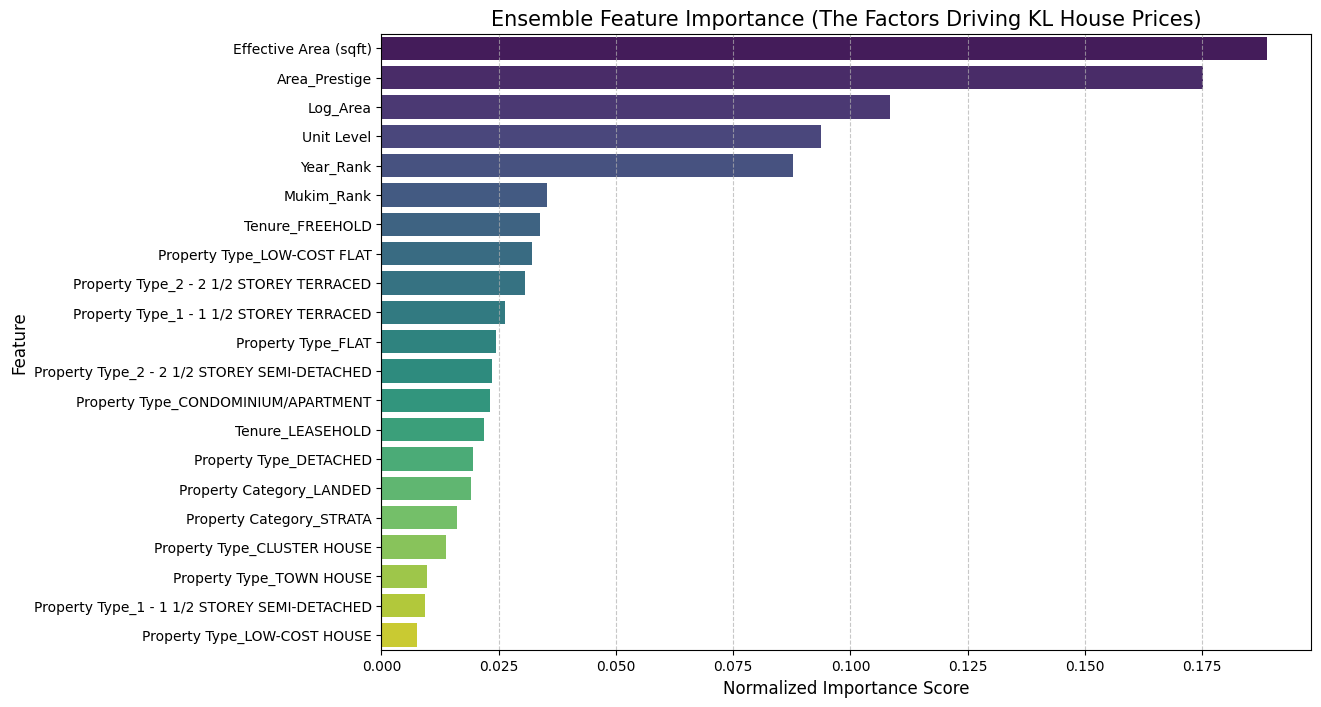

Top 5 Most Influential Features:
                  Feature  Importance
1   Effective Area (sqft)    0.188825
20          Area_Prestige    0.175201
18               Log_Area    0.108363
2              Unit Level    0.093624
19              Year_Rank    0.087708


In [22]:
# 1. Extract importances from each model
# Note: We normalize them so they are on the same scale (0 to 1)
rf_imp = tuned_rf.feature_importances_ / np.sum(tuned_rf.feature_importances_)
xgb_imp = tuned_xgb.feature_importances_ / np.sum(tuned_xgb.feature_importances_)
lgbm_imp = tuned_lgbm.feature_importances_ / np.sum(tuned_lgbm.feature_importances_)

# 2. Average the importances
avg_imp = (rf_imp + xgb_imp + lgbm_imp) / 3

# 3. Create a DataFrame for plotting
feat_names = X_train_final.columns
importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': avg_imp})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 4. Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Ensemble Feature Importance (The Factors Driving KL House Prices)', fontsize=15)
plt.xlabel('Normalized Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# --- VERIFICATION ---
print("Top 5 Most Influential Features:")
print(importance_df.head(5))

##Model Selection

The best model - Random Forest Classifier with a final F1 score of 0.8548 was save and exported to a pkl file. The next step would be integrating the trained model into the data product.

In [23]:
import pickle

# We save the best estimator from your Random Forest GridSearch
champion_model = rf_grid.best_estimator_

model_filename = 'kl_property_model_rf.pkl'

with open(model_filename, 'wb') as f:
    pickle.dump(champion_model, f)

print(f"✅ Champion Model saved as: {model_filename}")

✅ Champion Model saved as: kl_property_model_rf.pkl


## Data Modelling Report

### 3-Class Price Category Pivot

Initially, the project explored a 4-class property categorization ('Budget', 'Mid-Range', 'High-End', 'Luxury'). However, this approach resulted in a model with relatively low performance, particularly struggling to differentiate effectively between 'Mid-Range' and 'High-End' properties. To address this, the team pivoted to a 3-class categorization:

*   **Budget** (Transaction Price < 500,000)
*   **Mid-Range** (500,000 <= Transaction Price < 1,200,000)
*   **Luxury** (Transaction Price >= 1,200,000)

This re-binning strategy, implemented using `pd.cut` with `price_bins = [0, 500000, 1200000, float('inf')]` and `price_labels = [0, 1, 2]`, created a more balanced distribution of classes. The 'Budget' category emerged as the majority (11,376 transactions), followed by 'Mid-Range' (8,914 transactions), and 'Luxury' (3,842 transactions), providing a more distinct target for the models.

### Manual Class Weighting

To further combat potential class imbalance issues, especially considering the fewer 'Luxury' properties, a manual class-weighting strategy was employed. Instead of using a 'balanced' weight which would heavily penalize errors on minority classes, custom weights were defined:

*   **Class 0 (Budget):** 1.0
*   **Class 1 (Mid-Range):** 1.0
*   **Class 2 (Luxury):** 1.5

This assigns a 50% higher importance to correctly classifying 'Luxury' properties, ensuring that models, particularly XGBoost, focus more on these less frequent but high-value transactions. These `custom_weights` were then mapped to the training labels (`y_train`) to create `custom_sample_weights`, used during the fitting of ensemble models.

### Random Forest Tuning

The Random Forest Classifier, identified as a top performer, underwent hyperparameter tuning using `GridSearchCV` to optimize its performance and reduce overfitting. The `rf_param_grid` explored various combinations of:

*   `n_estimators`: [100, 200] (number of trees)
*   `max_depth`: [10, 15, 20] (maximum depth of each tree)
*   `min_samples_leaf`: [2, 4, 6] (minimum samples required to be at a leaf node)
*   `max_features`: ['sqrt', 'log2'] (number of features to consider when looking for the best split)
*   `class_weight`: The `custom_weights` dictionary was applied here as well to maintain the desired class importance during tuning.

The `GridSearchCV` used `f1_weighted` as the scoring metric, which is more robust than accuracy for imbalanced datasets, and `cv=3` for cross-validation. The tuning process aimed to find a balance between model complexity and generalization ability. The `best_estimator_` obtained from this tuning was then used in the final ensemble model, achieving a Final Tuned RF Accuracy of **0.8548** on the test set.

## Data Interpretation Report

### Confusion Matrix Analysis (Random Forest)

The Confusion Matrix for the best-performing model, Random Forest, provides a detailed breakdown of its classification performance on the unseen test set. With a final test accuracy of **0.8488**, let's analyze the classification report:

*   **Budget (Class 0):**
    *   **Precision (0.90):** 90% of properties predicted as 'Budget' were actually 'Budget'. This is a high precision, indicating few false positives for this category.
    *   **Recall (0.90):** 90% of actual 'Budget' properties were correctly identified. This shows the model is good at catching most 'Budget' properties.
    *   **F1-Score (0.90):** A strong balance between precision and recall for the majority class.
    *   **Support (2275):** This is the largest class in the test set, and the model performs very well here.

*   **Mid-Range (Class 1):**
    *   **Precision (0.80):** 80% of properties predicted as 'Mid-Range' were actually 'Mid-Range'.
    *   **Recall (0.80):** 80% of actual 'Mid-Range' properties were correctly identified.
    *   **F1-Score (0.80):** Good performance, though slightly lower than 'Budget', indicating some confusion with adjacent classes.
    *   **Support (1783):** A significant portion of the test set, and performance is solid.

*   **Luxury (Class 2):**
    *   **Precision (0.82):** 82% of properties predicted as 'Luxury' were actually 'Luxury'. This is a good precision for a minority class, showing the model is quite reliable when it predicts 'Luxury'.
    *   **Recall (0.82):** 82% of actual 'Luxury' properties were correctly identified. This is a very positive outcome, especially given the smaller sample size (769 support) and the emphasis on this class through custom weighting.
    *   **F1-Score (0.82):** This reflects a good balance for the 'Luxury' category, demonstrating the effectiveness of the class weighting strategy.

Overall, the Random Forest model shows strong and balanced performance across all three price categories, with high precision and recall, especially for the 'Luxury' class, which was a specific focus due to its importance.

### Feature Importance Plot Analysis

The Ensemble Feature Importance plot, derived by averaging the normalized importances from the tuned Random Forest, XGBoost, and LightGBM models, highlights the most influential factors driving property prices in Kuala Lumpur. The top 5 most influential features are:

1.  **Effective Area (sqft) (0.188825):** This is the single most important feature, indicating that the total usable area of a property is the primary driver of its price. Larger properties naturally command higher prices.

2.  **Area_Prestige (0.175201):** This synthesized feature, created by multiplying `Log_Area` by `Mukim_Rank`, ranks as the second most influential. It effectively captures the 'value density' of a property by combining its size with the prestige of its location. This indicates that a large property in a high-ranking (prestigious) `Mukim` has a significantly higher impact on price than just size or location alone. This feature is particularly powerful in predicting luxury properties.

3.  **Log_Area (0.108363):** The log-transformed effective area. While `Effective Area (sqft)` itself is top, its logarithmic transformation also holds significant predictive power. This suggests that the relationship between area and price might not be purely linear; the log transformation helps the model capture diminishing returns or non-linear effects of increasing area, especially for very large properties.

4.  **Unit Level (0.093624):** This feature, likely representing the floor level of a unit (especially relevant for stratified properties), is the fourth most important. This can capture aspects like views, accessibility, or noise levels, which directly influence property value.

5.  **Year_Rank (0.087708):** This interaction feature, derived from `Transaction Year * Mukim_Rank`, signifies the importance of the transaction year in the context of the location's prestige. It suggests that the market dynamics (inflation, economic shifts) over time have a varying impact depending on the prestige of the `Mukim`, allowing the model to adjust price category thresholds based on when the transaction occurred.

In summary, the analysis confirms that traditional metrics like area are crucial, but engineered features like `Area_Prestige` and `Year_Rank`, which combine intrinsic property characteristics with contextual factors like location prestige and time, are extremely powerful in predicting property price categories.